# NB02: Preprocesamiento multimodal (isomiRs miRNA / isoformas mRNA)

**Fase 2** del pipeline SupraGraphNet. Procesa las dos modalidades ómicas de TCGA-HNSC: isomiRs miRNA e isoformas de ARNm . Todos los filtros se calculan exclusivamente sobre la cohorte tumoral; las muestras normales reciben pasivamente el mismo índice de features para preservar la comparabilidad en el sanity check de la Fase 4.

**Entradas (NB01):** `barcodes_por_tipo_muestra.json`, `survival_targets_all_patients.csv`  
**Entradas (raw):** `miRNA_HiSeq_gene.txt`, `isoforms.txt`  
**Salidas:** `mirna_matrix_tumor.pt`, `isoforma_matrix_tumor.pt`, `mirna_matrix_normal.pt`, `isoforma_matrix_normal.pt`, `selected_mirna_ids.txt`, `selected_isoforma_ids.txt`, `patient_barcodes_tumor.txt`, `survival_targets_final.csv`

## 0. Setup y rutas

Montaje de Google Drive, instalación de dependencias e importación de librerías. Se verifican los ficheros de entrada necesarios.

In [2]:
from google.colab import drive
import os
import sys

# 1. Montar Google Drive
drive.mount('/content/drive')

# 2. Moverse a la carpeta del proyecto
carpeta_proyecto = '/content/drive/MyDrive/TFM'
os.chdir(carpeta_proyecto)

# 3. Añadir la ruta al system path
sys.path.append(carpeta_proyecto)

print("Directorio de trabajo actual:", os.getcwd())

Mounted at /content/drive
Directorio de trabajo actual: /content/drive/MyDrive/TFM


In [3]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.4 MB/s eta 0:00:00


In [4]:
import json
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from scipy import stats
from statsmodels.stats.multitest import multipletests

project_root = Path.cwd()
sys.path.append(str(project_root / "src"))

from hnsc_graph.preprocessing import (
    setup_logging,
    filter_low_expression_by_cpm,
    log2_cpm,
)

setup_logging()
sns.set(style="whitegrid")

BASE_DIR      = Path(r"/content/drive/MyDrive/TFM/data")
PROCESSED_DIR = BASE_DIR / "processed_hnsc"

# ── Archivos de expresión ─────────────────────────────────────────────────
MIRNA_FILE = BASE_DIR / "miRNA_HiSeq_gene.txt"
MRNA_FILE  = BASE_DIR / "isoforms.txt"

# ── Archivos de NB01 ─────────────────────────────────────────────────────
BARCODES_JSON = PROCESSED_DIR / "barcodes_por_tipo_muestra.json"
TARGETS_FILE  = PROCESSED_DIR / "survival_targets_all_patients.csv"

for p in [MIRNA_FILE, MRNA_FILE, BARCODES_JSON, TARGETS_FILE]:
    print(f"{'OK' if p.exists() else 'FALTA'} : {p.name}")

OK : miRNA_HiSeq_gene.txt
OK : isoforms.txt
OK : barcodes_por_tipo_muestra.json
OK : survival_targets_all_patients.csv


## Paso 1: Carga de barcodes y targets de supervivencia

Lee los barcodes separados por tipo de muestra (tumor / normal) generados en NB01 y los targets de supervivencia. Define los dos conjuntos de pacientes: cohorte de entrenamiento tumoral y cohorte normal para sanity check.

In [5]:

# CARGA DE BARCODES: separación tumor / normal


with open(BARCODES_JSON) as f:
    barcodes_json = json.load(f)

# Tumor primario + metástasis como cohorte de entrenamiento
barcodes_tumor  = barcodes_json.get("tumor", []) + barcodes_json.get("metastasis", [])
barcodes_normal = barcodes_json.get("normal", [])

# Targets de supervivencia (solo existen para tumor)
targets_df = pd.read_csv(TARGETS_FILE, index_col=0)

print(f"Barcodes tumor (train)  : {len(barcodes_tumor)}")
print(f"Barcodes normal (sanity): {len(barcodes_normal)}")
print(f"Targets cargados        : {len(targets_df)} pacientes")
print(f"  Fallecidos  (OS=1)    : {int((targets_df['OS']==1).sum())}")
print(f"  Censurados  (OS=0)    : {int((targets_df['OS']==0).sum())}")
print()
targets_df.head()

Barcodes tumor (train)  : 530
Barcodes normal (sanity): 74
Targets cargados        : 527 pacientes
  Fallecidos  (OS=1)    : 223
  Censurados  (OS=0)    : 304



,OS,OS.time,hpv_status,hpv_positive,os_group,es_pareado
barcode_12,,,,,,
TCGA-4P-AA8J,0,102.0,HPV-,0.0,censored,False
TCGA-BA-4074,1,462.0,HPV-,0.0,deceased,False
TCGA-BA-4075,1,283.0,HPV-,0.0,deceased,False
TCGA-BA-4076,1,415.0,HPV-,0.0,deceased,False
TCGA-BA-4077,1,1134.0,HPV+,1.0,deceased,False


## Paso 2: Preprocesamiento isomiRs miRNA

### Inspección del fichero raw

Carga el fichero miRNA HiSeq para verificar orientación (MIMATs × muestras) y tipos de índice.

In [6]:
mi_df_raw = pd.read_csv(MIRNA_FILE, sep="\t", index_col=0)
print(f"Shape: {mi_df_raw.shape}")
print("Primeras columnas:", mi_df_raw.columns[:3].tolist())
print("Primeras filas index:", mi_df_raw.index[:3].tolist())

Shape: (2246, 529)
Primeras columnas: ['TCGA-CV-A45Q-01', 'TCGA-BA-5149-01', 'TCGA-UF-A7JJ-01']
Primeras filas index: ['MIMAT0019868', 'MIMAT0019869', 'MIMAT0019860']


### Filtrado y normalización (solo tumor)

Separa submatrices tumor/normal antes de cualquier filtro. Sobre tumor: elimina MIMATs con >80% NaN, muestras con >50% NaN, rellena NaN restantes con 0 y aplica filtro de baja expresión (log2(RPM+1) ≥ 1 en ≥20% de muestras). Resultado: **590 MIMATs** en la cohorte tumoral.

In [8]:

# PROCESAMIENTO miRNA: HNSC


mi_df = pd.read_csv(MIRNA_FILE, sep="\t", index_col=0)
print(f"Dimensiones originales: {mi_df.shape} (MIMATs x muestras)")
print(f"% NaN global: {mi_df.isna().mean().mean()*100:.1f}%")

# ── 1) Normalizar barcode a 15 caracteres ────────────────────────────────
mi_df.columns = mi_df.columns.astype(str).str.slice(0, 15)

# ── 2) Separar submatrices tumor y normal ANTES de cualquier filtro ───────
mi_tumor  = mi_df.loc[:, mi_df.columns.isin(barcodes_tumor)].copy()
mi_normal = mi_df.loc[:, mi_df.columns.isin(barcodes_normal)].copy()
print(f"Muestras tumor  encontradas en miRNA: {mi_tumor.shape[1]}")
print(f"Muestras normal encontradas en miRNA: {mi_normal.shape[1]}")

# A partir de aquí: TODOS los filtros sobre TUMOR


# ── 3) Filtrar MIMATs con >80% NaN en tumor ───────────────────────────────
nan_mimat  = mi_tumor.isna().mean(axis=1)
mask_mimat = nan_mimat <= 0.8
mi_tumor   = mi_tumor.loc[mask_mimat]
print(f"\nTras quitar MIMATs >80% NaN (tumor): {mi_tumor.shape[0]} MIMATs "
      f"({(~mask_mimat).sum()} eliminados)")

# ── 4) Filtrar muestras tumor con >50% NaN ────────────────────────────────
nan_muestras  = mi_tumor.isna().mean(axis=0)
mask_muestras = nan_muestras <= 0.5
mi_tumor      = mi_tumor.loc[:, mask_muestras]
print(f"Tras quitar muestras tumor >50% NaN: {mi_tumor.shape[1]} muestras "
      f"({(~mask_muestras).sum()} eliminadas)")

# ── 5) Rellenar NaN restantes con 0 ──────────────────────────────────────
mi_tumor = mi_tumor.fillna(0)

# ── 6) Transponer tumor → [muestras x MIMATs] ────────────────────────────
mirna_expr_tumor = mi_tumor.T.copy()
mirna_expr_tumor.index.name = "sample_barcode"

# ── 7) Filtrado de baja expresión (solo tumor) ────────────────────────────
# Criterio: log2(RPM+1) >= 1 en al menos 20% de muestras tumor
n_muestras_tumor = mirna_expr_tumor.shape[0]
mask_expr        = (mirna_expr_tumor >= 1).sum(axis=0) >= (0.2 * n_muestras_tumor)
mirna_expr_tumor = mirna_expr_tumor.loc[:, mask_expr].copy()

# ── Guardar índice de MIMATs seleccionados ───────────────────────────────
selected_mirna_ids = mirna_expr_tumor.columns.tolist()

print(f"\nMatriz final miRNA (tumor):")
print(f"  Muestras : {mirna_expr_tumor.shape[0]}")
print(f"  MIMATs   : {mirna_expr_tumor.shape[1]}")
print(f"  Rango    : [{mirna_expr_tumor.values.min():.3f}, {mirna_expr_tumor.values.max():.3f}]")
print(f"  Media    : {mirna_expr_tumor.values.mean():.3f}")
print(f"  Mediana  : {np.median(mirna_expr_tumor.values):.3f}")
pct_ceros = (mirna_expr_tumor.values == 0).mean() * 100
print(f"  % ceros  : {pct_ceros:.1f}%")

Dimensiones originales: (2246, 529) (MIMATs x muestras)
% NaN global: 61.5%
Muestras tumor  encontradas en miRNA: 485
Muestras normal encontradas en miRNA: 44

Tras quitar MIMATs >80% NaN (tumor): 1101 MIMATs (1145 eliminados)
Tras quitar muestras tumor >50% NaN: 485 muestras (0 eliminadas)

Matriz final miRNA (tumor):
  Muestras : 485
  MIMATs   : 590
  Rango    : [0.000, 19.590]
  Media    : 4.077
  Mediana  : 2.880
  % ceros  : 4.0%


## Paso 3: Preprocesamiento isoformas mRNA

El fichero RSEM contiene `normalized_count` en escala lineal UQ (verificado: max ~314k, mediana ~7.8 → no es log2). Se aplican tres filtros secuenciales calculados solo sobre tumor: F1 (UQ≥1 en ≥20% muestras), F2 (fracción ceros ≤75%), F3 (mediana >1.0). Normalización final: log2(UQ+1). Resultado: **44.670 isoformas** supervivientes (de 73.599 originales, 39% reducción), que pasan al análisis de señal de supervivencia.

In [9]:

# PROCESAMIENTO Isoformas mRNA
# Filtros (criterios estándar RNA-Seq):
# F1: UQ >= 1 en al menos 20% de muestras tumor
# F2: fracción de ceros <= 75%
# F3: mediana de expresión > 1.0


mrna_wide = pd.read_csv(MRNA_FILE, sep="\t", low_memory=False)

# ── 1) Eliminar fila de tipos ─────────────────────────────────────────────
mrna_wide = mrna_wide[mrna_wide["Hybridization REF"] != "isoform_id"].copy()
mrna_wide = mrna_wide.rename(columns={"Hybridization REF": "isoform_id"})

# ── 2) Mapear columnas a barcodes 15 caracteres ───────────────────────────
sample_cols = [c for c in mrna_wide.columns if c != "isoform_id"]
barcode_map = {c: str(c)[:15] for c in sample_cols}
mrna_wide   = mrna_wide.set_index("isoform_id")[sample_cols].rename(columns=barcode_map)

# ── 3) Convertir a numérico ───────────────────────────────────────────────
mrna_wide = mrna_wide.apply(pd.to_numeric, errors="coerce")

# ── 4) Agregar duplicados (múltiples alícuotas del mismo barcode) ─────────
mrna_wide = mrna_wide.T.groupby(level=0).mean().T

# ── 5) Separar submatrices tumor y normal ANTES de filtros ───────────────
common_tumor  = [b for b in barcodes_tumor  if b in mrna_wide.columns]
common_normal = [b for b in barcodes_normal if b in mrna_wide.columns]

mrna_matrix_tumor  = mrna_wide[common_tumor].T    # [muestras_tumor x isoformas]
mrna_matrix_normal = mrna_wide[common_normal].T   # [muestras_normal x isoformas]

print(f"Muestras tumor  en mRNA : {mrna_matrix_tumor.shape[0]}")
print(f"Muestras normal en mRNA : {mrna_matrix_normal.shape[0]}")
print(f"Isoformas totales (antes de filtrado): {mrna_matrix_tumor.shape[1]}")


# A partir de aquí: TODOS los filtros sobre TUMOR


# ── 6a) F1: UQ >= 1 en al menos 20% de muestras tumor ────────────────────
mask_f1 = (mrna_matrix_tumor >= 1.0).mean(axis=0) >= 0.2
mrna_f1 = mrna_matrix_tumor.loc[:, mask_f1].copy()
print(f"\nF1  UQ>=1 en >=20% muestras tumor    : {mrna_f1.shape[1]} isoformas "
      f"(eliminadas: {mrna_matrix_tumor.shape[1]-mrna_f1.shape[1]})")

# ── 6b) F2: fracción de ceros <= 75% en tumor ────────────────────────────
mask_f2 = (mrna_f1 == 0).mean(axis=0) <= 0.75
mrna_f2 = mrna_f1.loc[:, mask_f2].copy()
print(f"F2  fracción ceros <=75% (tumor)      : {mrna_f2.shape[1]} isoformas "
      f"(eliminadas: {mrna_f1.shape[1]-mrna_f2.shape[1]})")

# ── 6c) F3: mediana de expresión > 1.0 en tumor ──────────────────────────
mask_f3 = mrna_f2.median(axis=0) > 1.0
mrna_matrix_f = mrna_f2.loc[:, mask_f3].copy()
print(f"F3  mediana expresión > 1.0 (tumor)   : {mrna_matrix_f.shape[1]} isoformas "
      f"(eliminadas: {mrna_f2.shape[1]-mrna_matrix_f.shape[1]})")

print(f"\nResumen filtrado:")
print(f"  Original      : {mrna_matrix_tumor.shape[1]} isoformas")
print(f"  Tras F1+F2+F3 : {mrna_matrix_f.shape[1]} isoformas "
      f"({(1-mrna_matrix_f.shape[1]/mrna_matrix_tumor.shape[1])*100:.0f}% reducción)")

# ── 7) Normalización sobre tumor ──────────────────────────────
mrna_expr_full_tumor = np.log2(mrna_matrix_f + 1.0)
print(f"\nIsoformas mRNA tumor normalizadas log2(UQ+1): {mrna_expr_full_tumor.shape}")
print(f"Rango   : [{mrna_expr_full_tumor.values.min():.3f}, {mrna_expr_full_tumor.values.max():.3f}]")
print(f"Media   : {mrna_expr_full_tumor.values.mean():.3f} | Mediana: {np.median(mrna_expr_full_tumor.values):.3f}")

Muestras tumor  en mRNA : 522
Muestras normal en mRNA : 44
Isoformas totales (antes de filtrado): 73599

F1  UQ>=1 en >=20% muestras tumor    : 55117 isoformas (eliminadas: 18482)
F2  fracción ceros <=75% (tumor)      : 54259 isoformas (eliminadas: 858)
F3  mediana expresión > 1.0 (tumor)   : 44670 isoformas (eliminadas: 9589)

Resumen filtrado:
  Original      : 73599 isoformas
  Tras F1+F2+F3 : 44670 isoformas (39% reducción)

Isoformas mRNA tumor normalizadas log2(UQ+1): (522, 44670)
Rango   : [0.000, 21.743]
Media   : 5.752 | Mediana: 5.839


## Paso 4: EDA de normalización: verificación visual

Valida visualmente que ambas ómicas están correctamente normalizadas: histogramas globales, boxplots por muestra (30 aleatorias) y, para mRNA, gráfico de barras con el número de isoformas supervivientes tras cada filtro. Una segunda figura muestra la distribución de fracción de ceros post-filtrado en ambas ómicas.

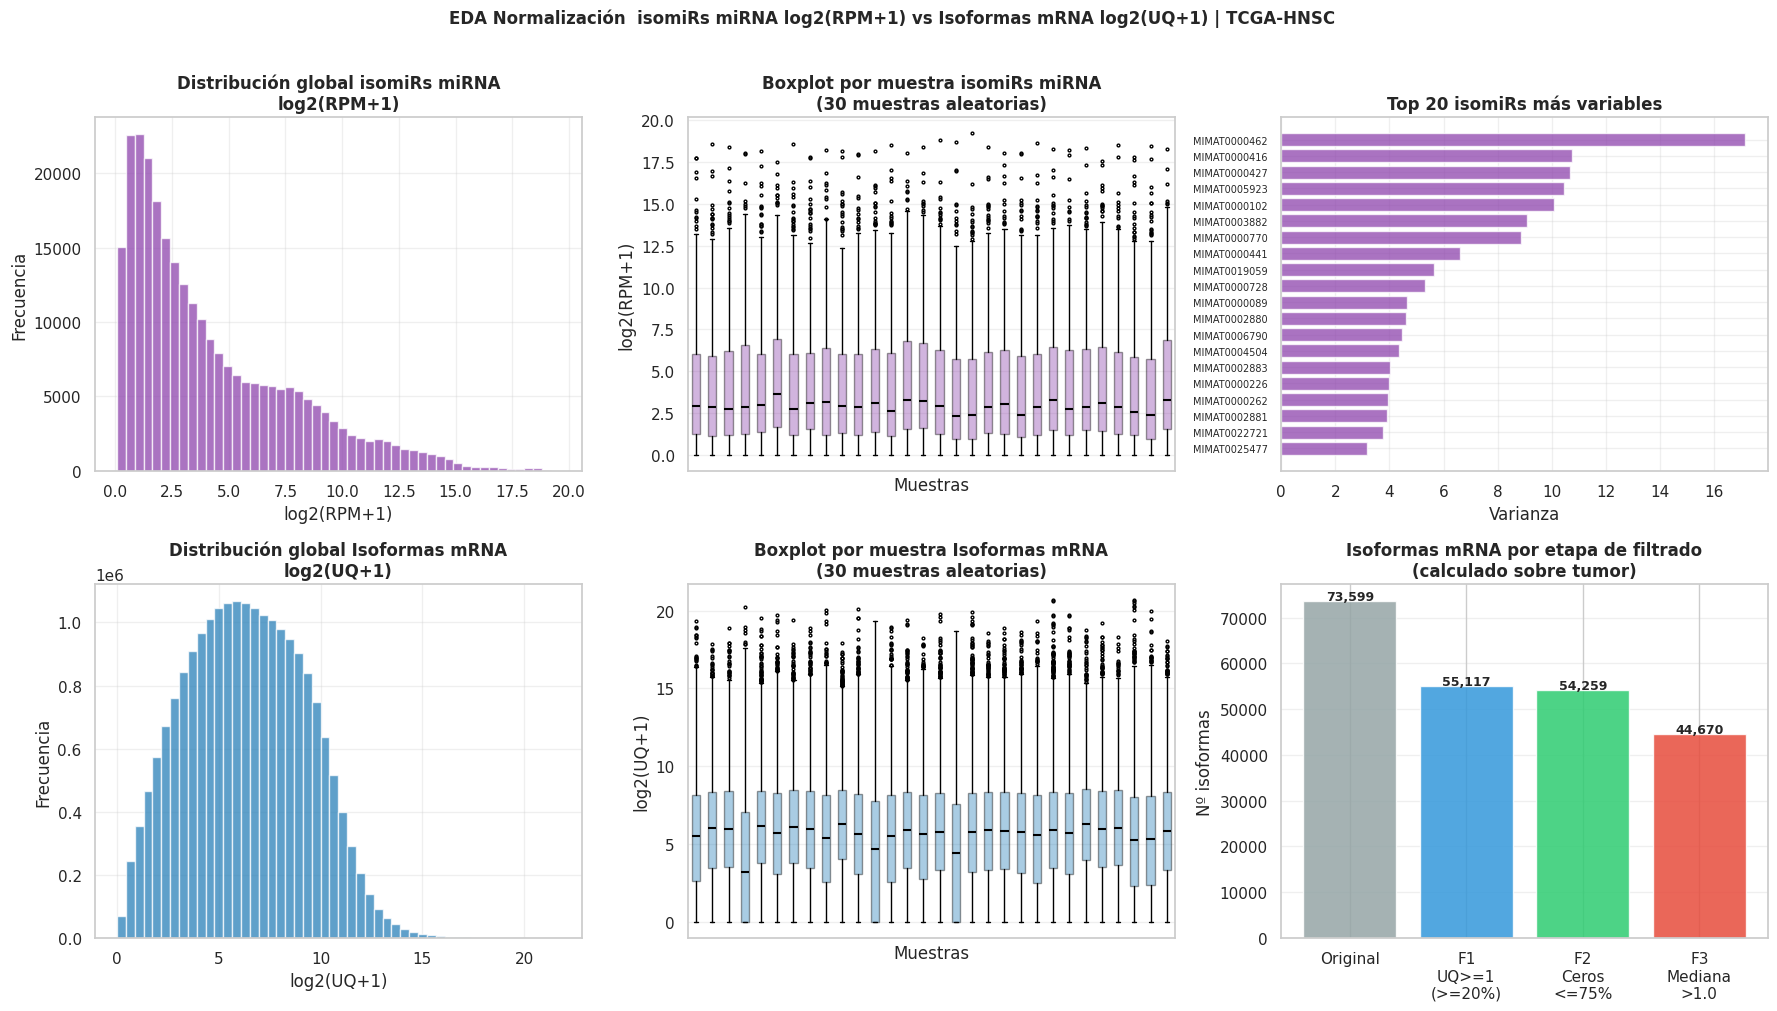

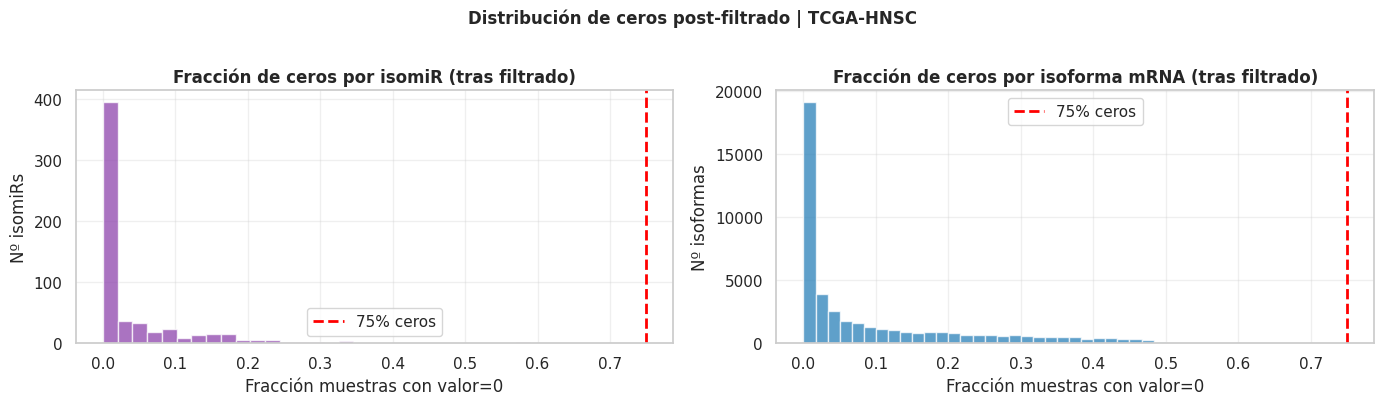

In [10]:

# EDA NORMALIZACIÓN + FILTRADO verificación visual


fig, axes = plt.subplots(2, 3, figsize=(18, 10))
np.random.seed(42)

# ── Fila 1: isomiRs miRNA ─────────────────────────────────────────────────
vals_mirna = mirna_expr_tumor.values.flatten()
axes[0,0].hist(vals_mirna[vals_mirna > 0], bins=50,
               color="#8e44ad", alpha=0.75, edgecolor="white")
axes[0,0].set_title("Distribución global isomiRs miRNA\nlog2(RPM+1)", fontweight="bold")
axes[0,0].set_xlabel("log2(RPM+1)"); axes[0,0].set_ylabel("Frecuencia")
axes[0,0].grid(alpha=0.3)

idx_s = np.random.choice(len(mirna_expr_tumor), size=min(30, len(mirna_expr_tumor)), replace=False)
axes[0,1].boxplot(mirna_expr_tumor.iloc[idx_s].T.values, patch_artist=True,
                  boxprops=dict(facecolor="#8e44ad", alpha=0.4),
                  medianprops=dict(color="black", linewidth=1.5),
                  flierprops=dict(markersize=2))
axes[0,1].set_title("Boxplot por muestra isomiRs miRNA\n(30 muestras aleatorias)", fontweight="bold")
axes[0,1].set_xlabel("Muestras"); axes[0,1].set_ylabel("log2(RPM+1)")
axes[0,1].set_xticks([]); axes[0,1].grid(alpha=0.3)

top_var_mirna = mirna_expr_tumor.var(axis=0).nlargest(20)
axes[0,2].barh(range(20), top_var_mirna.values[::-1], color="#8e44ad", alpha=0.75)
axes[0,2].set_yticks(range(20))
axes[0,2].set_yticklabels(top_var_mirna.index[::-1], fontsize=7)
axes[0,2].set_title("Top 20 isomiRs más variables", fontweight="bold")
axes[0,2].set_xlabel("Varianza"); axes[0,2].grid(alpha=0.3)

# ── Fila 2: Isoformas mRNA ────────────────────────────────────────────────
vals_mrna = mrna_expr_full_tumor.values.flatten()
axes[1,0].hist(vals_mrna[vals_mrna > 0], bins=50,
               color="#2980b9", alpha=0.75, edgecolor="white")
axes[1,0].set_title("Distribución global Isoformas mRNA\nlog2(UQ+1)", fontweight="bold")
axes[1,0].set_xlabel("log2(UQ+1)"); axes[1,0].set_ylabel("Frecuencia")
axes[1,0].grid(alpha=0.3)

idx_s2 = np.random.choice(len(mrna_expr_full_tumor), size=min(30, len(mrna_expr_full_tumor)), replace=False)
axes[1,1].boxplot(mrna_expr_full_tumor.iloc[idx_s2].T.values, patch_artist=True,
                  boxprops=dict(facecolor="#2980b9", alpha=0.4),
                  medianprops=dict(color="black", linewidth=1.5),
                  flierprops=dict(markersize=2))
axes[1,1].set_title("Boxplot por muestra Isoformas mRNA\n(30 muestras aleatorias)", fontweight="bold")
axes[1,1].set_xlabel("Muestras"); axes[1,1].set_ylabel("log2(UQ+1)")
axes[1,1].set_xticks([]); axes[1,1].grid(alpha=0.3)

# ── [1,2] Impacto de cada filtro ─────────────────────────────────────────
etapas  = ["Original", "F1\nUQ>=1\n(>=20%)", "F2\nCeros\n<=75%", "F3\nMediana\n>1.0"]
valores = [mrna_matrix_tumor.shape[1], mrna_f1.shape[1], mrna_f2.shape[1], mrna_matrix_f.shape[1]]
colores = ["#95a5a6", "#3498db", "#2ecc71", "#e74c3c"]
bars = axes[1,2].bar(etapas, valores, color=colores, alpha=0.85, edgecolor="white")
for bar, val in zip(bars, valores):
    axes[1,2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                   f"{val:,}", ha="center", fontsize=9, fontweight="bold")
axes[1,2].set_title("Isoformas mRNA por etapa de filtrado\n(calculado sobre tumor)", fontweight="bold")
axes[1,2].set_ylabel("Nº isoformas")
axes[1,2].grid(axis="y", alpha=0.3)

plt.suptitle(
    "EDA Normalización  isomiRs miRNA log2(RPM+1) vs Isoformas mRNA log2(UQ+1) | TCGA-HNSC",
    fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# ── Fracción de ceros post-filtrado ──────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 4))
zero_frac_mirna = (mirna_expr_tumor == 0).mean(axis=0)
zero_frac_mrna  = (mrna_expr_full_tumor == 0).mean(axis=0)
axes2[0].hist(zero_frac_mirna, bins=30, color="#8e44ad", alpha=0.75, edgecolor="white")
axes2[0].axvline(0.75, color="red", linestyle="--", linewidth=2, label="75% ceros")
axes2[0].set_title("Fracción de ceros por isomiR (tras filtrado)", fontweight="bold")
axes2[0].set_xlabel("Fracción muestras con valor=0")
axes2[0].set_ylabel("Nº isomiRs"); axes2[0].legend(); axes2[0].grid(alpha=0.3)
axes2[1].hist(zero_frac_mrna, bins=30, color="#2980b9", alpha=0.75, edgecolor="white")
axes2[1].axvline(0.75, color="red", linestyle="--", linewidth=2, label="75% ceros")
axes2[1].set_title("Fracción de ceros por isoforma mRNA (tras filtrado)", fontweight="bold")
axes2[1].set_xlabel("Fracción muestras con valor=0")
axes2[1].set_ylabel("Nº isoformas"); axes2[1].legend(); axes2[1].grid(alpha=0.3)
plt.suptitle("Distribución de ceros post-filtrado | TCGA-HNSC",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## Paso 5: Normalización de índices a 12 caracteres

Las matrices de expresión usan barcodes de 15 caracteres (TCGA-XX-XXXX-01); `targets_df` usa 12 (TCGA-XX-XXXX). Se truncan los índices para permitir el cruce.

In [11]:

# NORMALIZACIÓN DE ÍNDICES A 12 CARACTERES
# targets_df usa formato TCGA-XX-XXXX (12 chars)
# las matrices de expresión traen TCGA-XX-XXXX-01 (15 chars)


mirna_expr_tumor.index     = mirna_expr_tumor.index.str.slice(0, 12)
mrna_expr_full_tumor.index = mrna_expr_full_tumor.index.str.slice(0, 12)

print("targets_df       :", targets_df.index[:2].tolist())
print("mirna_expr_tumor :", mirna_expr_tumor.index[:2].tolist())
print("mrna_expr_tumor  :", mrna_expr_full_tumor.index[:2].tolist())


targets_df       : ['TCGA-4P-AA8J', 'TCGA-BA-4074']
mirna_expr_tumor : ['TCGA-CV-A45Q', 'TCGA-BA-5149']
mrna_expr_tumor  : ['TCGA-4P-AA8J', 'TCGA-BA-4074']


## Paso 6: Análisis de señal de supervivencia en isoformas mRNA

Calcula la correlación de Spearman entre la expresión de cada isoforma y OS.time sobre los **220 fallecidos** (OS=1) de la cohorte tumoral (223 originales menos 3 duplicados generados al truncar barcodes). El análisis Q1 vs Q4 fue descartado por falta de poder estadístico (grupos pequeños + >50k tests → FDR≈1 tras corrección BH). Se preseleccionan el top 10.000 por varianza para reducir el número de tests.

In [13]:

# ANÁLISIS DE SEÑAL DE SUPERVIVENCIA Isoformas mRNA


# Preselección: top 10.000 isoformas por varianza (reduce tests)
# y definición de deceased_idx y os_time_dec

# Top 10k por varianza sobre tumor
variances    = mrna_expr_full_tumor.var(axis=0)
mrna_top10k  = mrna_expr_full_tumor[variances.nlargest(10000).index].copy()

# Fallecidos — índice alineado con mrna_expr_full_tumor (12 chars)
deceased_mask = targets_df['OS'] == 1
deceased_idx  = [i for i in targets_df[deceased_mask].index
                 if i in mrna_top10k.index]
os_time_dec   = targets_df.loc[deceased_idx, 'OS.time']

print(f"Isoformas preseleccionadas (top varianza): {mrna_top10k.shape[1]}")
print(f"Fallecidos con datos mRNA               : {len(deceased_idx)}")

# Eliminar duplicados de índice generados al truncar barcodes
mrna_top10k      = mrna_top10k[~mrna_top10k.index.duplicated(keep='first')]
os_time_dec      = os_time_dec[~os_time_dec.index.duplicated(keep='first')]

# Re-filtrar deceased_idx para que coincida exactamente
deceased_idx = [i for i in deceased_idx if i in mrna_top10k.index]
mrna_dec     = mrna_top10k.loc[deceased_idx]
os_time_dec  = targets_df.loc[deceased_idx, "OS.time"]

print(f"Fallecidos tras deduplicar: {len(deceased_idx)}")
print(f"Shape mrna_dec    : {mrna_dec.shape}")
print(f"Shape os_time_dec : {os_time_dec.shape}")

corr_vals = []
pvals     = []
for col in mrna_top10k.columns:
    r, p = stats.spearmanr(mrna_dec[col].values, os_time_dec.values)
    corr_vals.append(r)
    pvals.append(p)

# ── Corrección FDR sobre los 10.000 tests ────────────────────────────────
_, fdr_10k, _, _ = multipletests(pvals, method="fdr_bh")

corr_results = pd.DataFrame({
    "isoform"    : mrna_top10k.columns,
    "spearman_r" : corr_vals,
    "pval"       : pvals,
    "FDR"        : fdr_10k,
    "abs_r"      : np.abs(corr_vals),
    "neg_log10p" : -np.log10(np.array(pvals) + 1e-300),
}).set_index("isoform")

# ── Resumen ───────────────────────────────────────────────────────────────
n_fdr05   = (corr_results["FDR"] < 0.05).sum()
n_fdr10   = (corr_results["FDR"] < 0.10).sum()
n_pnom_r2 = ((corr_results["pval"] < 0.05) & (corr_results["abs_r"] >= 0.2)).sum()
n_pnom    = (corr_results["pval"] < 0.05).sum()

print(f"\nResultados correlación Spearman (n={len(deceased_idx)} fallecidos):")
print(f"  FDR < 0.05              : {n_fdr05} isoformas")
print(f"  FDR < 0.10              : {n_fdr10} isoformas")
print(f"  p < 0.05 nominal        : {n_pnom} isoformas")
print(f"  p < 0.05 y |r| >= 0.6   : {n_pnom_r2} isoformas")
print()
print("Top 10 isoformas más correlacionadas con OS.time:")
print(corr_results.sort_values("abs_r", ascending=False).head(10)
      [["spearman_r","pval","FDR"]].to_string())

Isoformas preseleccionadas (top varianza): 10000
Fallecidos con datos mRNA               : 220
Fallecidos tras deduplicar: 220
Shape mrna_dec    : (220, 10000)
Shape os_time_dec : (220,)

Resultados correlación Spearman (n=220 fallecidos):
  FDR < 0.05              : 0 isoformas
  FDR < 0.10              : 0 isoformas
  p < 0.05 nominal        : 1108 isoformas
  p < 0.05 y |r| >= 0.6   : 95 isoformas

Top 10 isoformas más correlacionadas con OS.time:
            spearman_r      pval       FDR
isoform                                   
uc001aov.3   -0.277829  0.000029  0.151214
uc003wty.2    0.277296  0.000030  0.151214
uc003gvy.3    0.263767  0.000075  0.178246
uc002fix.2    0.263425  0.000077  0.178246
uc010pmv.1    0.261072  0.000089  0.178246
uc010vvo.1   -0.250918  0.000169  0.200745
uc002uzx.3    0.249167  0.000189  0.200745
uc004cfm.3    0.245756  0.000232  0.200745
uc011mjf.1   -0.243909  0.000260  0.200745
uc004aob.1    0.243741  0.000262  0.200745


### Visualización de la señal de supervivencia

Tres paneles: volcano-style (r vs −log10(p)), distribución de correlaciones y top 20 isoformas más correlacionadas con OS.time.

POS (p<0.05, r>= 0.2) : 74   más expresión → mayor supervivencia
NEG (p<0.05, r<=-0.2) : 21   más expresión → menor supervivencia
SIG_WEAK (p<0.05, r<0.2): 1013
NS                    : 8892


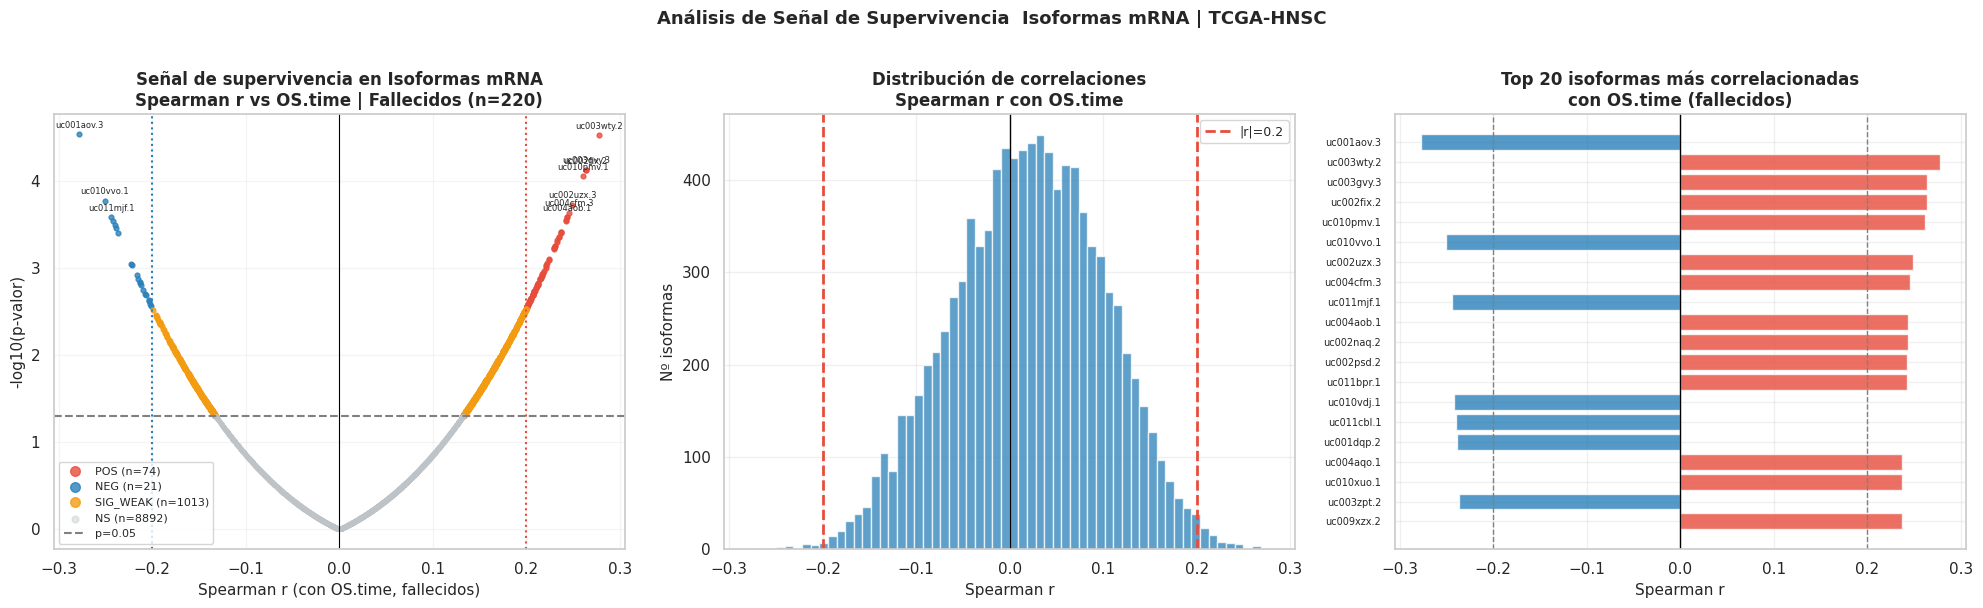

In [14]:

# GRÁFICOS: Señal de supervivencia en isoformas mRNA


r_thresh = 0.2
p_thresh = 0.05

corr_results["category"] = "NS"
corr_results.loc[
    (corr_results["pval"] < p_thresh) & (corr_results["spearman_r"] >= r_thresh),
    "category"
] = "POS"   # más expresión → más OS.time (mejor pronóstico)
corr_results.loc[
    (corr_results["pval"] < p_thresh) & (corr_results["spearman_r"] <= -r_thresh),
    "category"
] = "NEG"   # más expresión → menos OS.time (peor pronóstico)
corr_results.loc[
    (corr_results["pval"] < p_thresh) & (corr_results["abs_r"] < r_thresh),
    "category"
] = "SIG_WEAK"

color_map = {"POS": "#e74c3c", "NEG": "#2980b9",
             "SIG_WEAK": "#f39c12", "NS": "#bdc3c7"}

n_pos  = (corr_results["category"] == "POS").sum()
n_neg  = (corr_results["category"] == "NEG").sum()
n_weak = (corr_results["category"] == "SIG_WEAK").sum()
print(f"POS (p<0.05, r>= 0.2) : {n_pos}   más expresión → mayor supervivencia")
print(f"NEG (p<0.05, r<=-0.2) : {n_neg}   más expresión → menor supervivencia")
print(f"SIG_WEAK (p<0.05, r<0.2): {n_weak}")
print(f"NS                    : {(corr_results['category']=='NS').sum()}")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ── [0] Volcano-style ────────────────────────────────────────────────────
for cat, color in color_map.items():
    sub = corr_results[corr_results["category"] == cat]
    axes[0].scatter(sub["spearman_r"], sub["neg_log10p"],
                    c=color, alpha=0.4 if cat == "NS" else 0.8,
                    s=6 if cat == "NS" else 12,
                    label=f"{cat} (n={len(sub)})")

axes[0].axhline(-np.log10(p_thresh), color="gray", linestyle="--",
                linewidth=1.5, label=f"p={p_thresh}")
axes[0].axvline(r_thresh,  color="#e74c3c", linestyle=":", linewidth=1.5)
axes[0].axvline(-r_thresh, color="#2980b9", linestyle=":", linewidth=1.5)
axes[0].axvline(0, color="black", linewidth=0.8)

top10 = corr_results[corr_results["category"].isin(["POS","NEG"])].nlargest(10, "abs_r")
for iso, row in top10.iterrows():
    axes[0].annotate(iso, (row["spearman_r"], row["neg_log10p"]),
                     fontsize=6, ha="center", va="bottom",
                     xytext=(0, 3), textcoords="offset points")

axes[0].set_xlabel("Spearman r (con OS.time, fallecidos)", fontsize=11)
axes[0].set_ylabel("-log10(p-valor)", fontsize=11)
axes[0].set_title(
    "Señal de supervivencia en Isoformas mRNA\n"
    f"Spearman r vs OS.time | Fallecidos (n={len(deceased_idx)})",
    fontweight="bold")
axes[0].legend(fontsize=8, markerscale=2)
axes[0].grid(alpha=0.2)

# ── [1] Distribución de r ─────────────────────────────────────────────────
axes[1].hist(corr_results["spearman_r"], bins=60,
             color="#2980b9", alpha=0.75, edgecolor="white")
axes[1].axvline(r_thresh,  color="#e74c3c", linestyle="--",
                linewidth=2, label=f"|r|={r_thresh}")
axes[1].axvline(-r_thresh, color="#e74c3c", linestyle="--", linewidth=2)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_xlabel("Spearman r", fontsize=11)
axes[1].set_ylabel("Nº isoformas", fontsize=11)
axes[1].set_title("Distribución de correlaciones\nSpearman r con OS.time",
                  fontweight="bold")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

# ── [2] Top 20 más correlacionadas ───────────────────────────────────────
top20 = corr_results.nlargest(20, "abs_r")
colors_top = ["#e74c3c" if r > 0 else "#2980b9"
              for r in top20["spearman_r"]]
axes[2].barh(range(20), top20["spearman_r"].values[::-1],
             color=colors_top[::-1], alpha=0.8)
axes[2].set_yticks(range(20))
axes[2].set_yticklabels(top20.index[::-1], fontsize=7)
axes[2].axvline(0, color="black", linewidth=1)
axes[2].axvline(r_thresh,  color="gray", linestyle="--", linewidth=1)
axes[2].axvline(-r_thresh, color="gray", linestyle="--", linewidth=1)
axes[2].set_xlabel("Spearman r", fontsize=11)
axes[2].set_title("Top 20 isoformas más correlacionadas\ncon OS.time (fallecidos)",
                  fontweight="bold")
axes[2].grid(alpha=0.3)

plt.suptitle("Análisis de Señal de Supervivencia  Isoformas mRNA | TCGA-HNSC",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## Paso 7: Selección final de isoformas mRNA

Estrategia en dos pasos: (1) isoformas con p<0.05 y |r|≥0.15 sobre OS.time en fallecidos (634 isoformas con señal de supervivencia); (2) si el total es <3.000, complementar con top varianza hasta 5.000. Resultado: **5.305 isoformas** seleccionadas (634 con señal + 4.671 por varianza). El índice se guarda para aplicarlo pasivamente a las normales.

In [15]:

# SELECCIÓN FINAL DE ISOFORMAS mRNA


selected_isoforms = set()

# ── Paso 1: p<0.05 y |r|>=0.2 ────────────────────────────────────────────
mask_p1 = (corr_results["pval"] < 0.05) & (corr_results["abs_r"] >= 0.15)
sel_p1  = corr_results[mask_p1].index.tolist()
selected_isoforms.update(sel_p1)
print(f"Paso 1  p<0.05 y |r|>=0.2 : {len(sel_p1)} isoformas")


# ── Paso 2: complementar con top varianza hasta 5.000 ────────────────────
if len(selected_isoforms) < 3000:
    top_var = mrna_expr_full_tumor.var(axis=0).nlargest(5000).index.tolist()
    selected_isoforms.update(top_var)
    print(f"Paso 2  top varianza 5.000 : acumulado {len(selected_isoforms)} isoformas")
else:
    print(f"Paso 2  no necesario")

# ── Cap máximo 10.000 ordenado por |r| descendente ───────────────────────
corr_results_ext = corr_results.reindex(list(selected_isoforms))
corr_results_ext["abs_r"] = corr_results_ext["abs_r"].fillna(0)
selected_ordered = (
    corr_results_ext
    .sort_values("abs_r", ascending=False)
    .head(10000)
    .index.tolist()
)

# ── Matrices finales de tumor ─────────────────────────────────────────────
mrna_expr_tumor = mrna_expr_full_tumor[selected_ordered].copy()

# ── Guardar índice de isoformas seleccionadas ─────────────────────────────
selected_isoforma_ids = selected_ordered

print(f"\nIsoformas seleccionadas final : {len(selected_ordered)}")
print(f"  Con señal OS.time (p<0.05, |r|>=0.2) : {len(sel_p1)}")
print(f"  Complementadas por varianza           : {len(selected_ordered)-len(sel_p1)}")
print(f"Forma matriz mRNA tumor final          : {mrna_expr_tumor.shape}")

# Guardar corr_results completo para NB03/NB04
corr_results_out = PROCESSED_DIR / "corr_isoforms_ostime.csv"
corr_results.to_csv(corr_results_out)
print(f"\nResultados correlación guardados en: {corr_results_out.name}")

Paso 1  p<0.05 y |r|>=0.2 : 634 isoformas
Paso 2  top varianza 5.000 : acumulado 5305 isoformas

Isoformas seleccionadas final : 5305
  Con señal OS.time (p<0.05, |r|>=0.2) : 634
  Complementadas por varianza           : 4671
Forma matriz mRNA tumor final          : (522, 5305)

Resultados correlación guardados en: corr_isoforms_ostime.csv


## Paso 8: Alineación final de la cohorte tumoral

Calcula la intersección de pacientes con datos miRNA + isoformas mRNA + targets. Elimina duplicados generados al truncar a 12 caracteres. Resultado: **474 pacientes** alineados (198 fallecidos, 276 censurados).

In [16]:

# ALINEACIÓN FINAL  COHORTE TUMOR
# Intersección: pacientes con miRNA + isoformas mRNA + targets

# Eliminar duplicados de índice generados al truncar a 12 chars
mirna_expr_tumor = mirna_expr_tumor[~mirna_expr_tumor.index.duplicated(keep='first')]
mrna_expr_tumor  = mrna_expr_tumor[~mrna_expr_tumor.index.duplicated(keep='first')]
targets_df       = targets_df[~targets_df.index.duplicated(keep='first')]

set_mirna   = set(mirna_expr_tumor.index)
set_mrna    = set(mrna_expr_tumor.index)
set_targets = set(targets_df.index)

common_barcodes_tumor = sorted(set_mirna & set_mrna & set_targets)

print(f"Pacientes con miRNA         : {len(set_mirna)}")
print(f"Pacientes con isoformas mRNA: {len(set_mrna)}")
print(f"Pacientes con targets       : {len(set_targets)}")
print(f"Intersección final tumor    : {len(common_barcodes_tumor)}")
print()
sin_mirna = (set_targets & set_mrna) - set_mirna
sin_mrna  = (set_targets & set_mirna) - set_mrna
sin_ambos = set_targets - set_mirna - set_mrna
print(f"Sin datos miRNA             : {len(sin_mirna)}")
print(f"Sin datos isoformas mRNA    : {len(sin_mrna)}")
print(f"Sin datos ambos             : {len(sin_ambos)}")

# ── Alinear matrices tumor ────────────────────────────────────────────────
mirna_expr_tumor = mirna_expr_tumor.loc[common_barcodes_tumor]
mrna_expr_tumor  = mrna_expr_tumor.loc[common_barcodes_tumor]
targets_df       = targets_df.loc[common_barcodes_tumor]

print(f"\nCohorte tumor alineada      : {len(common_barcodes_tumor)} pacientes")
print(f"  miRNA             : {mirna_expr_tumor.shape}")
print(f"  Isoformas mRNA    : {mrna_expr_tumor.shape}")
print(f"  Fallecidos        : {int((targets_df['OS']==1).sum())} "
      f"| Censurados: {int((targets_df['OS']==0).sum())}")

Pacientes con miRNA         : 483
Pacientes con isoformas mRNA: 520
Pacientes con targets       : 527
Intersección final tumor    : 474

Sin datos miRNA             : 45
Sin datos isoformas mRNA    : 8
Sin datos ambos             : 0

Cohorte tumor alineada      : 474 pacientes
  miRNA             : (474, 590)
  Isoformas mRNA    : (474, 5305)
  Fallecidos        : 198 | Censurados: 276


## Paso 9: Aplicación pasiva del índice de features a muestras normales

Las muestras normales reciben exactamente el mismo subconjunto de MIMATs e isoformas seleccionado sobre tumor, sin recalcular ningún filtro (evita data leakage). De las 74 muestras normales del TCGA-HNSC, **44 están disponibles en ambas ómicas** (30 ausentes por falta de datos en miRNA o mRNA).

In [17]:

# APLICACIÓN PASIVA A MUESTRAS NORMALES


# ── miRNA normal aplicación pasiva ─────────────────────────────────────
# mi_normal ya tiene columnas en barcodes_normal (cargado en Cell miRNA)
mi_normal_t = mi_normal.T.copy()   # [muestras_normal x MIMATs]
mi_normal_t.index.name = "sample_barcode"

# Aplicar exactamente el mismo subconjunto de MIMATs seleccionados en tumor
# MIMATs que no existen en normal → rellenar con 0 (sin expresión detectada)
mirna_normal_aligned = mi_normal_t.reindex(columns=selected_mirna_ids, fill_value=0)
mirna_normal_aligned = mirna_normal_aligned.fillna(0)

print(f"miRNA normal (pasivo):")
print(f"  Muestras : {mirna_normal_aligned.shape[0]}")
print(f"  MIMATs   : {mirna_normal_aligned.shape[1]} (= {len(selected_mirna_ids)} seleccionados en tumor)")

# ── mRNA normal  aplicación pasiva ──────────────────────────────────────
# mrna_matrix_normal ya tiene columnas en barcodes_normal (cargado en Cell mRNA)
# Aplicar exactamente el mismo subconjunto de isoformas seleccionadas en tumor
# Isoformas ausentes en normal → rellenar con 0 antes de log2
mrna_normal_raw = mrna_matrix_normal.reindex(columns=selected_isoforma_ids, fill_value=0)
mrna_normal_raw = mrna_normal_raw.fillna(0)

# Misma normalización log2(UQ+1)
mrna_expr_normal = np.log2(mrna_normal_raw + 1.0)

print(f"\nmRNA normal (pasivo):")
print(f"  Muestras  : {mrna_expr_normal.shape[0]}")
print(f"  Isoformas : {mrna_expr_normal.shape[1]} (= {len(selected_isoforma_ids)} seleccionadas en tumor)")

# ── Alinear barcodes normales disponibles en ambas ómicas ─────────────────
set_mirna_normal = set(mirna_normal_aligned.index)
set_mrna_normal  = set(mrna_expr_normal.index)
common_barcodes_normal = sorted(set_mirna_normal & set_mrna_normal)

mirna_normal_aligned = mirna_normal_aligned.loc[common_barcodes_normal]
mrna_expr_normal     = mrna_expr_normal.loc[common_barcodes_normal]

print(f"\nCohorte normal alineada: {len(common_barcodes_normal)} pacientes")
print(f"  (esperados: 74  faltantes por ausencia en alguna ómica: "
      f"{74 - len(common_barcodes_normal)})")

miRNA normal (pasivo):
  Muestras : 44
  MIMATs   : 590 (= 590 seleccionados en tumor)

mRNA normal (pasivo):
  Muestras  : 44
  Isoformas : 5305 (= 5305 seleccionadas en tumor)

Cohorte normal alineada: 44 pacientes
  (esperados: 74  faltantes por ausencia en alguna ómica: 30)


In [18]:
mirna_normal_aligned.index = mirna_normal_aligned.index.str.slice(0, 12)
mrna_expr_normal.index     = mrna_expr_normal.index.str.slice(0, 12)
print("mirna_normal     :", mirna_normal_aligned.index[:2].tolist())
print("mrna_normal      :", mrna_expr_normal.index[:2].tolist())

mirna_normal     : ['TCGA-CV-6933', 'TCGA-CV-6934']
mrna_normal      : ['TCGA-CV-6933', 'TCGA-CV-6934']


## Paso 10: Guardado de tensores PyTorch y archivos de índice

Exporta las cuatro matrices como tensores float32 (convenio filas=pacientes), las listas de IDs biológicos seleccionados y los targets de supervivencia alineados. Incluye verificación anti-leakage explícita.

In [19]:

# GUARDADO  tensores PyTorch + archivos de índice


PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# ── Tensores tumor ────────────────────────────────────────────────────────
mirna_tensor_tumor   = torch.tensor(mirna_expr_tumor.values, dtype=torch.float32)
isoforma_tensor_tumor = torch.tensor(mrna_expr_tumor.values, dtype=torch.float32)

torch.save(mirna_tensor_tumor,    PROCESSED_DIR / "mirna_matrix_tumor.pt")
torch.save(isoforma_tensor_tumor, PROCESSED_DIR / "isoforma_matrix_tumor.pt")

# ── Tensores normal ───────────────────────────────────────────────────────
mirna_tensor_normal   = torch.tensor(mirna_normal_aligned.values, dtype=torch.float32)
isoforma_tensor_normal = torch.tensor(mrna_expr_normal.values, dtype=torch.float32)

torch.save(mirna_tensor_normal,    PROCESSED_DIR / "mirna_matrix_normal.pt")
torch.save(isoforma_tensor_normal, PROCESSED_DIR / "isoforma_matrix_normal.pt")

# ── Archivos de índice ────────────────────────────────────────────────────
with open(PROCESSED_DIR / "selected_mirna_ids.txt", "w") as f:
    f.write("\n".join(selected_mirna_ids))

with open(PROCESSED_DIR / "selected_isoforma_ids.txt", "w") as f:
    f.write("\n".join(selected_isoforma_ids))

with open(PROCESSED_DIR / "patient_barcodes_tumor.txt", "w") as f:
    f.write("\n".join(common_barcodes_tumor))

with open(PROCESSED_DIR / "patient_barcodes_normal.txt", "w") as f:
    f.write("\n".join(common_barcodes_normal))

# ── Targets alineados ─────────────────────────────────────────────────────
targets_df.to_csv(PROCESSED_DIR / "survival_targets_final.csv")

# ── Resumen final ─────────────────────────────────────────────────────────
print("═" * 60)
print("OUTPUTS NB02  guardados en:", PROCESSED_DIR)
print("═" * 60)
print(f"  mirna_matrix_tumor.pt          : {mirna_tensor_tumor.shape}   float32")
print(f"  isoforma_matrix_tumor.pt       : {isoforma_tensor_tumor.shape} float32")
print(f"  mirna_matrix_normal.pt         : {mirna_tensor_normal.shape}  float32")
print(f"  isoforma_matrix_normal.pt      : {isoforma_tensor_normal.shape} float32")
print(f"  selected_mirna_ids.txt         : {len(selected_mirna_ids)} MIMATs")
print(f"  selected_isoforma_ids.txt      : {len(selected_isoforma_ids)} isoformas")
print(f"  patient_barcodes_tumor.txt     : {len(common_barcodes_tumor)} pacientes")
print(f"  patient_barcodes_normal.txt    : {len(common_barcodes_normal)} pacientes")
print(f"  survival_targets_final.csv     : {targets_df.shape}")
print(f"  corr_isoforms_ostime.csv       : {corr_results.shape}")
print()
print("VERIFICACIÓN anti-leakage:")
print(f"  Filtros calculados sobre tumor : SÍ ({len(common_barcodes_tumor)} pacientes)")
print(f"  Normales filtradas pasivamente : SÍ ({len(common_barcodes_normal)} pacientes)")
print()
print("PRÓXIMO PASO: NB03  construcción del grafo heterogéneo PyG.")
print("  Usar: mirna_matrix_tumor.pt, isoforma_matrix_tumor.pt,")
print("        selected_mirna_ids.txt, selected_isoforma_ids.txt,")
print("        patient_barcodes_tumor.txt, survival_targets_final.csv")

════════════════════════════════════════════════════════════
OUTPUTS NB02  guardados en: /content/drive/MyDrive/TFM/data/processed_hnsc
════════════════════════════════════════════════════════════
  mirna_matrix_tumor.pt          : torch.Size([474, 590])   float32
  isoforma_matrix_tumor.pt       : torch.Size([474, 5305]) float32
  mirna_matrix_normal.pt         : torch.Size([44, 590])  float32
  isoforma_matrix_normal.pt      : torch.Size([44, 5305]) float32
  selected_mirna_ids.txt         : 590 MIMATs
  selected_isoforma_ids.txt      : 5305 isoformas
  patient_barcodes_tumor.txt     : 474 pacientes
  patient_barcodes_normal.txt    : 44 pacientes
  survival_targets_final.csv     : (474, 6)
  corr_isoforms_ostime.csv       : (10000, 6)

VERIFICACIÓN anti-leakage:
  Filtros calculados sobre tumor : SÍ (474 pacientes)
  Normales filtradas pasivamente : SÍ (44 pacientes)

PRÓXIMO PASO: NB03  construcción del grafo heterogéneo PyG.
  Usar: mirna_matrix_tumor.pt, isoforma_matrix_tumor.pt,


## Resumen de salidas

| Fichero | Dimensiones | Descripción |
|---|---|---|
| `mirna_matrix_tumor.pt` | (474 × 590) | isomiRs miRNA tumor, log2(RPM+1) |
| `isoforma_matrix_tumor.pt` | (474 × 5.305) | Isoformas mRNA tumor, log2(UQ+1) |
| `mirna_matrix_normal.pt` | (44 × 590) | isomiRs miRNA normal (pasivo) |
| `isoforma_matrix_normal.pt` | (44 × 5.305) | Isoformas mRNA normal (pasivo) |
| `selected_mirna_ids.txt` | 590 MIMATs | IDs biológicos seleccionados |
| `selected_isoforma_ids.txt` | 5.305 isoformas | IDs UCSC seleccionados |
| `patient_barcodes_tumor.txt` | 474 pacientes | Orden de filas en matrices tumor |
| `patient_barcodes_normal.txt` | 44 pacientes | Orden de filas en matrices normal |
| `survival_targets_final.csv` | (474 × 6) | Targets OS alineados con tumor |

**Cifras clave:** 474 pacientes tumor · 590 MIMATs · 5.305 isoformas · 44 normales alineadas (30 ausentes por datos faltantes en miRNA o mRNA) · filtros calculados exclusivamente sobre tumor.

**Siguiente:** NB03: Construcción del grafo heterogéneo PyTorch Geometric.